In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm
import torch

plt.style.use('ggplot')

import nltk

In [3]:
df = pd.read_csv("../Data/tripadvisor_hotel_reviews.csv")
df.head(1)

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4


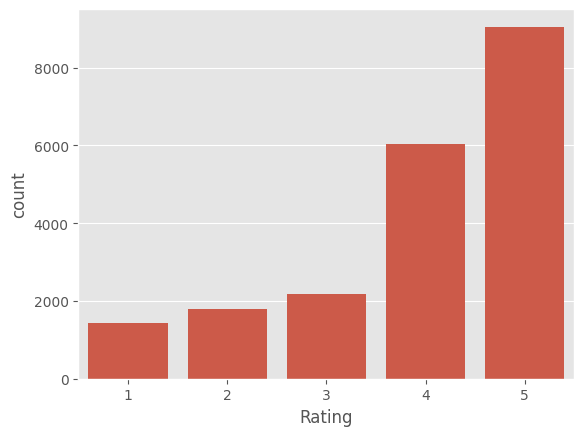

In [64]:
sns.countplot(data=df, x="Rating")
plt.show()

In [5]:
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax
tokenizer = AutoTokenizer.from_pretrained("minh21/XLNet-Reddit-Toxic-Comment-Classification")
model = AutoModelForSequenceClassification.from_pretrained("minh21/XLNet-Reddit-Toxic-Comment-Classification")
nlp = pipeline('sentiment-analysis', model=model, tokenizer=tokenizer)
text = list(df.Review.values)

Device set to use cpu


In [5]:
batch_size = 16
results = []

for i in range(0, len(df.Review), batch_size):
    batch = df.Review[i:i+batch_size].tolist()
    res = nlp(batch)
    results.extend(res)

In [56]:
df1 = pd.read_csv("../Data/pred.csv")
df1 = df1.drop("Unnamed: 0", axis=1)
data = pd.concat([df, df1], axis=1)
data["label"] = data["label"].map({'LABEL_0': 0, 'LABEL_1': 1})

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data['Review'], data['label'], test_size=0.2, random_state=42)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

tfidf_vectorizer = TfidfVectorizer()

train = tfidf_vectorizer.fit_transform(X_train)
test = tfidf_vectorizer.transform(X_test)

In [60]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression(random_state=42)
model.fit(train, y_train)
y_pred = model.predict(test)

In [62]:
from sklearn.metrics import precision_score, accuracy_score, f1_score, recall_score
round(accuracy_score(y_test, y_pred), 2), round(precision_score(y_test, y_pred), 2), round(f1_score(y_test, y_pred, average='weighted'), 3), round(recall_score(y_test, y_pred, average='weighted'), 2)

(0.92, 0.79, 0.896, 0.92)

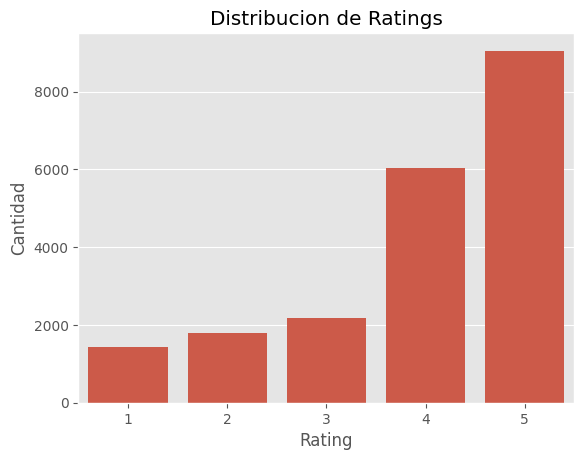

In [76]:
ax = sns.countplot(data=df, x="Rating")
ax.set_ylabel("Cantidad")
plt.title("Distribucion de Ratings")
plt.show()

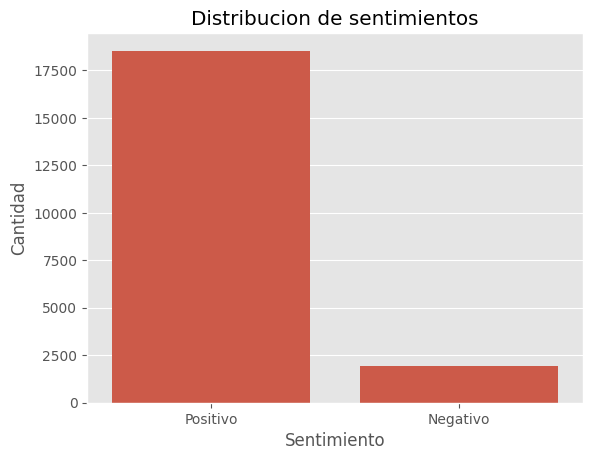

In [77]:
ax = sns.countplot(data=data, x="label")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Positivo", "Negativo"])
ax.set_xlabel("Sentimiento")
ax.set_ylabel("Cantidad")
plt.title("Distribucion de sentimientos")
plt.show()